# Lab 5 — Ensemble Detector (Random Forest)

**Day 06 · Anomaly Detection · Cisco AI/ML Training**

---

> **Quick check:** precision **1.00** · recall **0.50** · F1 ≈ **0.67**




## Random Forest for fraud

Use `class_weight='balanced'` to up-weight rare fraud without explicit oversampling.

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC_FEATURES = ["amount", "distance_from_home"]
CATEGORICAL_FEATURES = ["merchant_category"]

df = pd.read_csv(GH_ROOT / "data" / "credit-card" / "credit_card_transactions.csv")
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train: {len(X_train)} (fraud {int(y_train.sum())})")
print(f"test:  {len(X_test)} (fraud {int(y_test.sum())})")

# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Positive rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

train: 800 (fraud 8)
test:  200 (fraud 2)
Loaded 1,000 rows x 6 columns
dtypes: {'transaction_id': dtype('O'), 'timestamp': dtype('O'), 'amount': dtype('float64'), 'merchant_category': dtype('O'), 'distance_from_home': dtype('float64'), 'is_fraud': dtype('int64')}
Train: 800 | Test: 200
Positive rate — train: 1.00% | test: 1.00%


## Train Random Forest pipeline

In [3]:
N_ESTIMATORS = 100

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [4]:
pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=N_ESTIMATORS,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Lab 5 — Ensemble detector (Random Forest)")
print(f"estimators: {N_ESTIMATORS}, class_weight: balanced")

Lab 5 — Ensemble detector (Random Forest)
estimators: 100, class_weight: balanced


## Fraud-class metrics

In [5]:
f1 = f1_score(y_test, y_pred, zero_division=0)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print(f"precision (fraud): {precision:.4f}")
print(f"recall (fraud): {recall:.4f}")
print(f"F1 (fraud): {f1:.4f}")

metrics = pd.DataFrame({
    "metric": ["precision", "recall", "F1"],
    "fraud_class": [precision, recall, f1],
})
display(metrics.round(4))


precision (fraud): 1.0000
recall (fraud): 0.5000
F1 (fraud): 0.6667


,metric,fraud_class
0,precision,1.0000
1,recall,0.5000
2,F1,0.6667


## Predictions on test set

In [6]:
pred_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "amount": X_test["amount"].values,
    "distance_from_home": X_test["distance_from_home"].values,
})
display(pred_df.sort_values("predicted", ascending=False).head(8).round(2))


,actual,predicted,amount,distance_from_home
163,1,1,510.55,27.68
0,0,0,5.92,0.48
2,0,0,13.10,4.64
1,0,0,59.13,3.59
4,0,0,75.29,12.51
5,0,0,24.35,2.30
6,0,0,49.76,23.56
3,0,0,18.53,4.12


## Extension — n_estimators = 200

In [7]:
pipe_200 = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)
pipe_200.fit(X_train, y_train)
f1_200 = f1_score(y_test, pipe_200.predict(X_test), zero_division=0)

# cisco-debug-summary
print("Model fit complete.")

Model fit complete.


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [8]:
display(pd.DataFrame({
    "n_estimators": [100, 200],
    "F1_fraud": [f1, f1_200],
}).round(4))

,n_estimators,F1_fraud
0,100,0.6667
1,200,0.6667


## Feature importance (optional)

In [9]:
feature_names = (
    NUMERIC_FEATURES
    + list(pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES))
)
importances = pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(8)

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

C:\Users\PC\AppData\Local\Temp\ipykernel_22368\3681339660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="Blues_r")


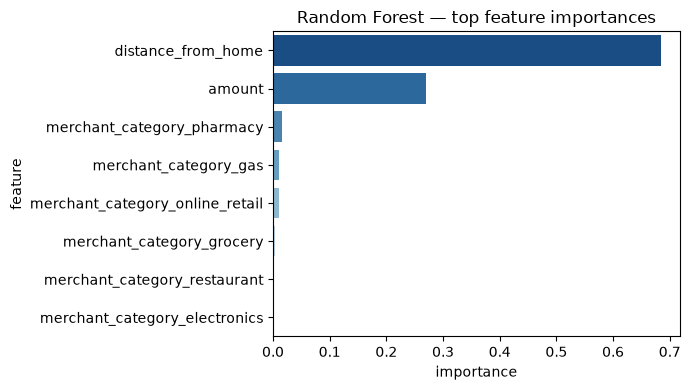

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="Blues_r")
ax.set_title("Random Forest — top feature importances")
plt.tight_layout()
plt.show()

### Random Forest prompt 1

Show predicted class counts.

In [11]:
print(pd.Series(y_pred).value_counts().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{0: 199, 1: 1}
Value counts — long tail categories may be omitted.


### Random Forest prompt 2

List test fraud rows and predictions.

In [12]:
display(pred_df.loc[pred_df['actual']==1].round(2))

,actual,predicted,amount,distance_from_home
73,1,0,45.73,38.33
163,1,1,510.55,27.68


### Random Forest prompt 3

Compute false positives count.

In [13]:
print(int(((y_pred==1)&(y_test==0)).sum()))

0


### Random Forest prompt 4

Compute false negatives count.

In [14]:
print(int(((y_pred==0)&(y_test==1)).sum()))

1


### Random Forest prompt 5

Show RF class distribution in train fit.

In [15]:
print(y_train.value_counts().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{0: 792, 1: 8}
Value counts — long tail categories may be omitted.


### Random Forest prompt 6

Display metrics dict.

In [16]:
print({'precision': round(precision,4), 'recall': round(recall,4), 'f1': round(f1,4)})

{'precision': 1.0, 'recall': 0.5, 'f1': 0.6667}


### Random Forest prompt 7

Compare F1 at 100 vs 200 trees.

In [17]:
print({'f1_100': round(f1,4), 'f1_200': round(f1_200,4)})

{'f1_100': 0.6667, 'f1_200': 0.6667}


### Random Forest prompt 8

Show top feature name.

In [18]:
print(imp_df.iloc[0]['feature'])

distance_from_home


### Random Forest prompt 9

Count features after one-hot.

In [19]:
print(len(feature_names))

9


### Random Forest prompt 10

Verify N_ESTIMATORS constant.

In [20]:
print(N_ESTIMATORS)

100


### Random Forest prompt 11

Show probability max for fraud class.

In [21]:
print(round(pipe.predict_proba(X_test)[:,1].max(), 4))

0.81


### Random Forest prompt 12

Summarize precision-recall tradeoff.

In [22]:
print('RF: perfect precision, partial recall on this split.')

RF: perfect precision, partial recall on this split.


### Random Forest prompt 13

Compare to LOF recall from Lab 4.

In [23]:
print('LOF recall=1.0 vs RF recall=0.5 here.')

LOF recall=1.0 vs RF recall=0.5 here.


### Random Forest prompt 14

List merchants in test fraud rows.

In [24]:
print(X_test.loc[y_test==1, 'merchant_category'].tolist())

['gas', 'travel']

### Random Forest prompt 15

Show amounts for predicted fraud.

In [25]:
print(pred_df.loc[pred_df['predicted']==1, 'amount'].round(2).tolist())

[510.55]


### Random Forest prompt 16

Reconfirm test fraud count.

In [26]:
print(int(y_test.sum()))

2


### Random Forest prompt 17

State ensemble intuition.

In [27]:
print('Bagging many trees stabilizes tabular fraud decisions.')

Bagging many trees stabilizes tabular fraud decisions.


### Random Forest prompt 18

Check pipeline steps.

In [28]:
print(pipe.named_steps.keys())

dict_keys(['preprocess', 'clf'])


### Random Forest prompt 19

Display imp_df top 3.

In [29]:
display(imp_df.head(3).round(4))

,feature,importance
1,distance_from_home,0.6839
0,amount,0.2698
6,merchant_category_pharmacy,0.0162


### Random Forest prompt 20

Bridge to capstone.

In [30]:
print('Lab 6 ranks logistic, LOF, RF, and baseline together.')

Lab 6 ranks logistic, LOF, RF, and baseline together.


### Lab 5 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [31]:
print("Lab 5 recap step 1: completed")

Lab 5 recap step 1: completed


### Lab 5 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 5 recap step 2: completed")

Lab 5 recap step 2: completed


### Lab 5 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 5 recap step 3: completed")

Lab 5 recap step 3: completed


### Lab 5 quick recap 4

Pause and summarize one takeaway from the previous cell before moving on.

In [34]:
print("Lab 5 recap step 4: completed")

Lab 5 recap step 4: completed


## Final checkpoint

In [35]:
assert N_ESTIMATORS == 100
assert abs(precision - 1.0) < 0.01
assert abs(recall - 0.5) < 0.01
assert abs(f1 - 0.6667) < 0.05
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

Why might a bank prefer RF over LOF for auto-decline rules?